In [1]:
import pandas as pd
import numpy as np

## Read data from W&Bs
The CSV being read into pandas is from a W&Bs' report.

In [2]:
dataframe = pd.read_csv('results-data/wandb_export_2025-07-28T07_38_43.318-04_00.csv')

In [3]:
N = 10

methods = [
    'eval-supervised-no-gnn', 'eval-supervised-v2-encoder',
    'eval-linear-probe-v2-encoder', 'eval-fine-tune-v2-encoder',
    'eval-linear-probe-v2-encoder-barlow-twins', 'eval-fine-tune-v2-encoder-barlow-twins',
    'eval-linear-probe-v2-encoder-bgrl', 'eval-fine-tune-v2-encoder-bgrl'
    ]

precision_matrix = None
recall_matrix = None
f1_matrix = None

for method in methods:
    method_df = dataframe[dataframe.Name.str.contains(method)]

    if method in ('eval-linear-probe-v2-encoder', 'eval-fine-tune-v2-encoder'):
        method_df = method_df[~method_df.Name.str.contains('barlow-twins')]
        method_df = method_df[~method_df.Name.str.contains('bgrl')]
    
    assert method_df.shape[0] == N

    prec_values = method_df.eval_precision.values[np.newaxis, :]
    recall_values = method_df.eval_recall.values[np.newaxis, :]
    f1_values = method_df.eval_f_score.values[np.newaxis, :]

    precision_matrix = prec_values if precision_matrix is None \
        else np.concatenate([precision_matrix, prec_values], axis=0)
    recall_matrix = recall_values if recall_matrix is None \
        else np.concatenate([recall_matrix, recall_values], axis=0)
    f1_matrix = f1_values if f1_matrix is None \
        else np.concatenate([f1_matrix, f1_values], axis=0)

In [7]:
print(f"Precision Means: {precision_matrix.mean(axis=1)}")
print(f"Recall Means: {recall_matrix.mean(axis=1)}")
print(f"F1 Means: {f1_matrix.mean(axis=1)}")


print(f"Precision std. dev.: {precision_matrix.std(axis=1)}")
print(f"Recall std. dev.: {recall_matrix.std(axis=1)}")
print(f"F1 std. dev.: {f1_matrix.std(axis=1)}")

Precision Means: [0.         0.30435782 0.05487252 0.3857232  0.00117603 0.37567746
 0.04558676 0.36966227]
Recall Means: [0.         0.16890854 0.02743626 0.22201678 0.00058801 0.22299843
 0.02279338 0.21195722]
F1 Means: [0.         0.21377458 0.03658168 0.27576221 0.00078402 0.27317609
 0.03039117 0.26369569]
Precision std. dev.: [0.         0.05756688 0.01154271 0.09141005 0.00039104 0.06257608
 0.02877908 0.07646348]
Recall std. dev.: [0.         0.03930668 0.00577135 0.05401567 0.00019552 0.04046382
 0.01438954 0.04708892]
F1 std. dev.: [0.         0.04466745 0.00769514 0.06635673 0.00026069 0.04757135
 0.01918606 0.05666311]


In [27]:
# from scipy.stats import f_oneway
from scipy.stats import ttest_ind
from scipy.stats import mannwhitneyu
# Compare No GNN (index=0) vs. GNN Supervised (index=1) using T-Test
# Alternate Hypothesis: Mean performance of supervised model with GNN is greater than mean performance without GNN.
# no_gnn_vs_gnn_test = ttest_ind(f1_matrix[1, :], f1_matrix[0, :], alternative='greater')
no_gnn_vs_gnn_test = mannwhitneyu(f1_matrix[1, :], f1_matrix[0, :], alternative='greater')

# Compare GNN Supervised (index=1) vs. GNN Linear Probe (index=2)
# Alternate Hypothesis New: Mean performance of supervised GNN model is greater than linear probe model
# gnn_vs_dino_linear_probe_ttest = ttest_ind(f1_matrix[1, :], f1_matrix[2, :], alternative='greater')
gnn_vs_dino_linear_probe_ttest = mannwhitneyu(f1_matrix[1, :], f1_matrix[2, :], alternative='greater')

# Compare GNN Supervised (index=1) vs. GNN Fine-Tune (index=3)
# Alternate Hypothesis: Mean performance of fine-tuned GNN model is greater than mean performance of supervised GNN
# gnn_vs_dino_fine_tune_ttest = ttest_ind(f1_matrix[3, :], f1_matrix[1, :], alternative='greater')

# gnn_vs_bgrl_linear_probe_ttest = ttest_ind(f1_matrix[1, :], f1_matrix[6, :], alternative='greater')
# gnn_vs_bgrl_fine_tune_ttest = ttest_ind(f1_matrix[7, :], f1_matrix[1, :], alternative='greater')

# gnn_vs_bt_linear_probe_ttest = ttest_ind(f1_matrix[1, :], f1_matrix[4, :], alternative='greater')
# gnn_vs_bt_fine_tune_ttest = ttest_ind(f1_matrix[5, :], f1_matrix[1, :], alternative='greater')

# dino_vs_bt_linear_probe_ttest = ttest_ind(f1_matrix[2, :], f1_matrix[4, :], alternative='greater')
# dino_vs_bt_fine_tune_ttest = ttest_ind(f1_matrix[3, :], f1_matrix[5, :], alternative='greater')

# dino_vs_bgrl_linear_probe_ttest = ttest_ind(f1_matrix[2, :], f1_matrix[6, :], alternative='greater')
# dino_vs_bgrl_fine_tune_ttest = ttest_ind(f1_matrix[3, :], f1_matrix[7, :], alternative='greater')

print(f"No GNN vs. GNN supervised model: {no_gnn_vs_gnn_test}")

print(f"GNN supervised vs. DINO linear probe model: {gnn_vs_dino_linear_probe_ttest}")
# print(f"GNN supervised vs. DINO fine-tuned model: {gnn_vs_dino_fine_tune_ttest}")

# print(f"GNN supervised vs. BGRL linear probe model: {gnn_vs_bgrl_linear_probe_ttest}")
# print(f"GNN supervised vs. BGRL fine-tuned model: {gnn_vs_bgrl_fine_tune_ttest}")

# print(f"GNN supervised vs. GBT linear probe model: {gnn_vs_bt_linear_probe_ttest}")
# print(f"GNN supervised vs. GBT fine-tuned model: {gnn_vs_bt_fine_tune_ttest}")

# print(f"DINO vs. GBT (linear probe): {dino_vs_bt_linear_probe_ttest}")
# print(f"DINO vs. GBT (fine-tune): {dino_vs_bt_fine_tune_ttest}")

# print(f"DINO vs. BGRL (linear probe): {dino_vs_bgrl_linear_probe_ttest}")
# print(f"DINO vs. BGRL (fine-tune): {dino_vs_bgrl_fine_tune_ttest}")

# prec_stats = f_oneway(precision_matrix[0, :], precision_matrix[1, :],
#                       precision_matrix[2, :], precision_matrix[3, :])
# recall_stats = f_oneway(recall_matrix[0, :], recall_matrix[1, :],
#                         recall_matrix[2, :], recall_matrix[3, :])
# f1_stats = f_oneway(f1_matrix[0, :], f1_matrix[1, :],
#                     f1_matrix[2, :], f1_matrix[3, :])

# print(f"Precision stats: {prec_stats}")
# print(f"Recall stats: {recall_stats}")
# print(f"F1 score stats: {f1_stats}")

No GNN vs. GNN supervised model: MannwhitneyuResult(statistic=100.0, pvalue=3.193222375218491e-05)
GNN supervised vs. DINO linear probe model: MannwhitneyuResult(statistic=100.0, pvalue=9.133589555477501e-05)


In [20]:
import seaborn as sns

f1_df = pd.DataFrame(f1_matrix.T, columns=[m.replace('-','_') for m in methods])

In [23]:
f1_df.columns

Index(['eval_supervised_no_gnn', 'eval_supervised_v2_encoder',
       'eval_linear_probe_v2_encoder', 'eval_fine_tune_v2_encoder',
       'eval_linear_probe_v2_encoder_barlow_twins',
       'eval_fine_tune_v2_encoder_barlow_twins',
       'eval_linear_probe_v2_encoder_bgrl', 'eval_fine_tune_v2_encoder_bgrl'],
      dtype='object')

array([[<Axes: title={'center': 'eval_supervised_v2_encoder'}>]],
      dtype=object)

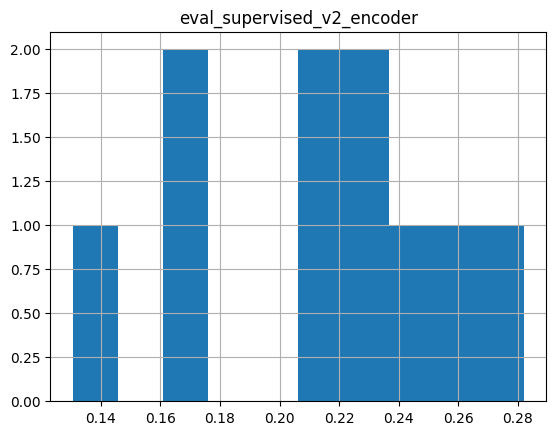

In [22]:
f1_df.hist('eval_supervised_v2_encoder')

array([[<Axes: title={'center': 'eval_supervised_no_gnn'}>]], dtype=object)

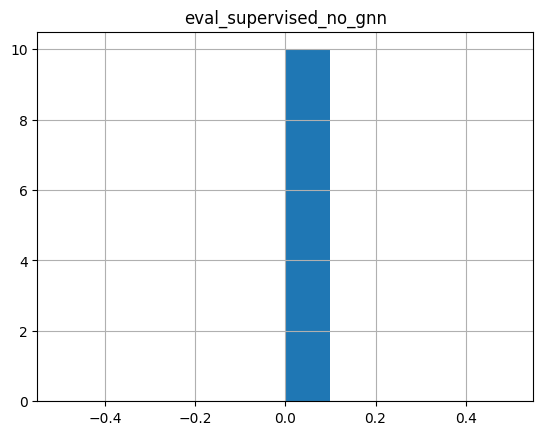

In [24]:
f1_df.hist('eval_supervised_no_gnn')

array([[<Axes: title={'center': 'eval_linear_probe_v2_encoder'}>]],
      dtype=object)

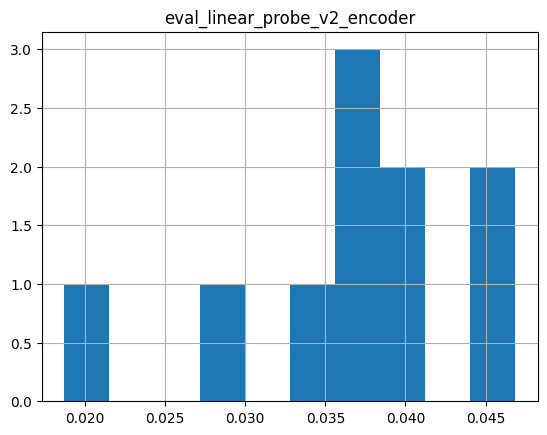

In [25]:
f1_df.hist('eval_linear_probe_v2_encoder')